In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

df = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/clustered_violations.csv")
cluster_summary = pd.read_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary_updated.csv")

df = df[df["cluster_id"] != -1].copy()
df["date"] = pd.to_datetime(df["date"])

print(f"Loaded {len(df):,} clustered records, {df['cluster_id'].nunique()} clusters")
df.head(3)

Loaded 86,073 clustered records, 30 clusters


,id,latitude,longitude,police_station,junction_name,junction_code,at_junction,created_dt,date,hour,...,violation_count,severity_score,is_parking_related,vehicle_type,vehicle_weight,validation_status,point_repeat_count,is_repeated_point,cluster_id,cluster_probability
0,FKID000000,12.925557,77.618665,Madiwala,No Junction,NaN,0,2023-11-20 00:28:46+00:00,2023-11-20,0,...,2,3,1,CAR,1.0,approved,1,0,7,0.633944
1,FKID000002,12.925449,77.618504,Madiwala,No Junction,NaN,0,2023-11-20 00:27:46+00:00,2023-11-20,0,...,2,4,1,CAR,1.0,approved,1,0,7,0.633944
2,FKID000003,12.956521,77.518618,Byatarayanapura,No Junction,NaN,0,2023-11-16 06:47:46+00:00,2023-11-16,6,...,1,2,1,SCOOTER,0.4,approved,1,0,12,1.000000


## 1. Persistence Analysis

Restricted to **Nov–Jan only** — complete months, per the earlier data gap
finding (Feb–Mar volume collapses 83–97%, which would artificially deflate
persistence scores if included).

```
persistence = active_days / total_days_in_window
```


In [3]:
complete = df[df["month_name"].isin(["November", "December", "January"])].copy()
total_days = complete["date"].nunique()

print(f"Complete window: {complete['date'].min().date()} to {complete['date'].max().date()}")
print(f"Total days in window: {total_days}")

active_days = (
    complete.groupby("cluster_id")["date"]
    .nunique()
    .reset_index(name="active_days")
)
active_days["persistence"] = active_days["active_days"] / total_days

active_days.sort_values("persistence", ascending=False)

Complete window: 2023-11-09 to 2024-01-31
Total days in window: 84


,cluster_id,active_days,persistence
13,13,84,1.000000
7,7,84,1.000000
29,29,84,1.000000
8,8,83,0.988095
12,12,83,0.988095
11,11,83,0.988095
21,21,83,0.988095
25,25,83,0.988095
27,27,83,0.988095
24,24,83,0.988095


## 2. Hotspot Classification

```
Structural : persistence > 0.6   → permanent enforcement / infrastructure need
Recurring  : 0.2 <= persistence <= 0.6 → scheduled patrol
Sporadic   : persistence < 0.2   → on-demand / event-driven response
```


In [4]:
def classify_persistence(p):
    if p > 0.6:
        return "Structural"
    elif p >= 0.2:
        return "Recurring"
    else:
        return "Sporadic"

active_days["hotspot_type"] = active_days["persistence"].apply(classify_persistence)

print(active_days["hotspot_type"].value_counts())
print()
active_days.sort_values("persistence", ascending=False)

hotspot_type
Structural    30
Name: count, dtype: int64



,cluster_id,active_days,persistence,hotspot_type
13,13,84,1.000000,Structural
7,7,84,1.000000,Structural
29,29,84,1.000000,Structural
8,8,83,0.988095,Structural
12,12,83,0.988095,Structural
11,11,83,0.988095,Structural
21,21,83,0.988095,Structural
25,25,83,0.988095,Structural
27,27,83,0.988095,Structural
24,24,83,0.988095,Structural


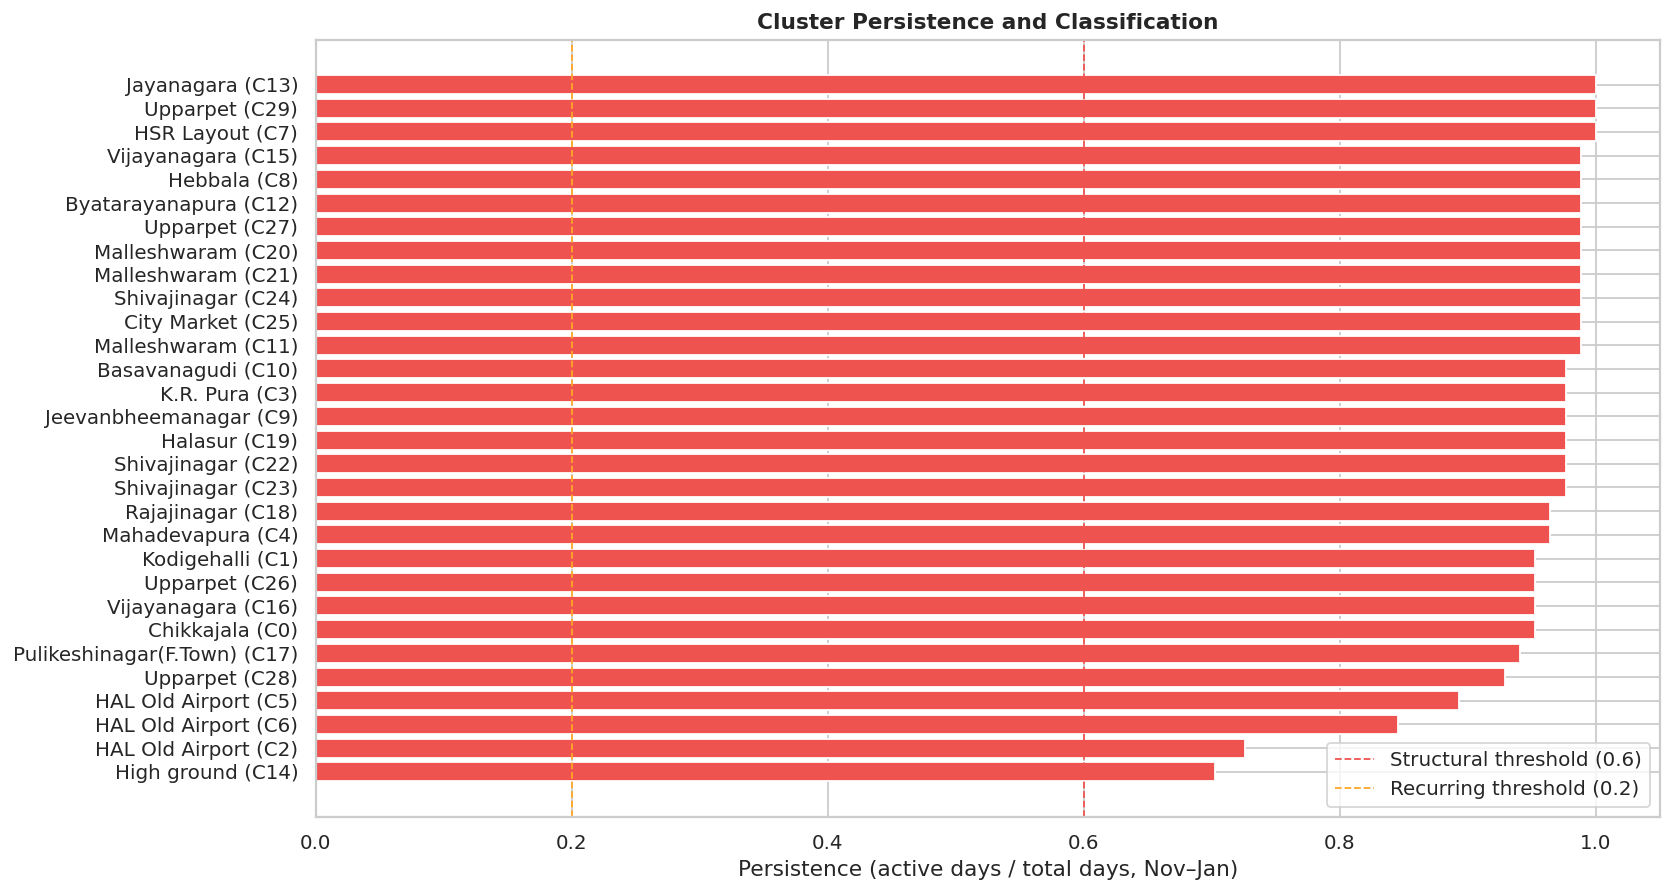

In [5]:
# Merge into cluster_summary
cluster_summary = cluster_summary.merge(
    active_days[["cluster_id", "active_days", "persistence", "hotspot_type"]],
    on="cluster_id", how="left"
)

fig, ax = plt.subplots(figsize=(13, 7))
color_map = {"Structural": "#EF5350", "Recurring": "#FFA726", "Sporadic": "#66BB6A"}
ordered = cluster_summary.sort_values("persistence", ascending=True)
bar_colors = ordered["hotspot_type"].map(color_map)

ax.barh(
    ordered["top_station"] + " (C" + ordered["cluster_id"].astype(str) + ")",
    ordered["persistence"],
    color=bar_colors
)
ax.axvline(0.6, color="#EF5350", ls="--", lw=1, label="Structural threshold (0.6)")
ax.axvline(0.2, color="#FFA726", ls="--", lw=1, label="Recurring threshold (0.2)")
ax.set_xlabel("Persistence (active days / total days, Nov–Jan)")
ax.set_title("Cluster Persistence and Classification", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("s4_persistence_classification.png")
plt.show()

## 3. Per-Cluster-Per-Day Feature Table

Built for **all months** (not just Nov–Jan) since Isolation Forest looks for
anomalies in day-to-day behaviour, not overall presence — a quiet Feb/Mar day
is still a valid data point for "what does this cluster's daily pattern look
like," it's just sparser.

Features per cluster-day:
| Feature | Description |
|---|---|
| `violations_count` | Total violations that day |
| `violations_per_hour_std` | Spread vs spikiness of hourly distribution |
| `avg_severity` | Average severity score that day |
| `junction_pct` | % of violations at a junction |
| `avg_vehicle_weight` | Vehicle mix (weight proxy) |
| `multi_violation_pct` | % of challans with 2+ violations |


In [6]:
daily_features = (
    df.groupby(["cluster_id", "date"])
    .agg(
        violations_count     = ("id", "count"),
        avg_severity         = ("severity_score", "mean"),
        junction_pct         = ("at_junction", "mean"),
        avg_vehicle_weight   = ("vehicle_weight", "mean"),
        multi_violation_pct  = ("violation_count", lambda x: (x > 1).mean()),
    )
    .reset_index()
)

# Hourly spread per cluster-day (std of violations across hours that day)
hourly_std = (
    df.groupby(["cluster_id", "date", "hour"])
    .size()
    .reset_index(name="count")
    .groupby(["cluster_id", "date"])["count"]
    .std()
    .fillna(0)
    .reset_index(name="violations_per_hour_std")
)

daily_features = daily_features.merge(hourly_std, on=["cluster_id", "date"], how="left")
daily_features["violations_per_hour_std"] = daily_features["violations_per_hour_std"].fillna(0)

print(f"Cluster-day rows: {len(daily_features):,}")
daily_features.head()

Cluster-day rows: 2,909


,cluster_id,date,violations_count,avg_severity,junction_pct,avg_vehicle_weight,multi_violation_pct,violations_per_hour_std
0,0,2023-11-09,6,2.333333,0.0,1.000000,0.166667,0.000000
1,0,2023-11-11,1,4.000000,0.0,1.000000,1.000000,0.000000
2,0,2023-11-13,4,4.000000,0.0,1.000000,1.000000,1.414214
3,0,2023-11-14,21,2.857143,0.0,1.000000,0.428571,3.095696
4,0,2023-11-15,31,2.064516,0.0,0.825806,0.032258,4.015595


## 4. Train Isolation Forest

Unsupervised — no labels needed. Trained on the daily feature table above to
learn what "normal" day-to-day behaviour looks like per cluster, then flags
rows that deviate.

`contamination=0.05` assumes roughly 5% of cluster-days are genuinely
anomalous — a reasonable starting assumption, adjustable later if the
flagged set looks too large or small on inspection.


In [7]:
FEATURE_COLS = [
    "violations_count",
    "avg_severity",
    "junction_pct",
    "avg_vehicle_weight",
    "multi_violation_pct",
    "violations_per_hour_std",
]

X = daily_features[FEATURE_COLS].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1,
)
iso_forest.fit(X_scaled)

daily_features["anomaly_score"] = iso_forest.decision_function(X_scaled)
daily_features["is_anomaly"]    = iso_forest.predict(X_scaled) == -1

print(f"Flagged anomalous cluster-days: {daily_features['is_anomaly'].sum():,} "
      f"({daily_features['is_anomaly'].mean() * 100:.1f}%)")
daily_features.sort_values("anomaly_score").head(10)

Flagged anomalous cluster-days: 146 (5.0%)


,cluster_id,date,violations_count,avg_severity,junction_pct,avg_vehicle_weight,multi_violation_pct,violations_per_hour_std,anomaly_score,is_anomaly
721,7,2024-03-09,1,4.000000,1.000000,2.500000,1.000000,0.000000,-0.139526,True
1245,12,2024-03-18,1,4.000000,1.000000,2.000000,1.000000,0.000000,-0.134355,True
1239,12,2024-03-12,1,4.000000,1.000000,2.000000,1.000000,0.000000,-0.134355,True
473,5,2023-12-08,88,3.909091,0.000000,0.943182,0.954545,38.686776,-0.130356,True
591,6,2024-01-11,207,3.043478,0.000000,0.661353,0.531401,25.469153,-0.127653,True
597,6,2024-01-17,235,2.400000,0.000000,0.516170,0.246809,27.661646,-0.123434,True
1214,12,2024-01-15,97,3.793814,0.278351,1.338144,0.907216,10.121609,-0.114683,True
613,6,2024-03-12,136,2.838235,0.000000,0.627206,0.705882,34.890304,-0.112582,True
708,7,2024-02-04,1,4.000000,1.000000,1.500000,1.000000,0.000000,-0.110110,True
616,6,2024-03-15,151,3.046358,0.000000,0.592715,0.569536,21.490446,-0.105747,True


## 5. Inspect Flagged Anomalies

Lower `anomaly_score` = more anomalous. Inspect the most extreme cases to
sanity-check they make sense (e.g. a sudden spike in violations on a specific
day, not just noise).


In [8]:
top_anomalies = daily_features.sort_values("anomaly_score").head(15).copy()
top_anomalies = top_anomalies.merge(
    cluster_summary[["cluster_id", "top_station"]], on="cluster_id", how="left"
)

top_anomalies[[
    "cluster_id", "top_station", "date",
    "violations_count", "avg_severity",
    "anomaly_score", "is_anomaly",
]]

,cluster_id,top_station,date,violations_count,avg_severity,anomaly_score,is_anomaly
0,7,HSR Layout,2024-03-09,1,4.000000,-0.139526,True
1,12,Byatarayanapura,2024-03-18,1,4.000000,-0.134355,True
2,12,Byatarayanapura,2024-03-12,1,4.000000,-0.134355,True
3,5,HAL Old Airport,2023-12-08,88,3.909091,-0.130356,True
4,6,HAL Old Airport,2024-01-11,207,3.043478,-0.127653,True
5,6,HAL Old Airport,2024-01-17,235,2.400000,-0.123434,True
6,12,Byatarayanapura,2024-01-15,97,3.793814,-0.114683,True
7,6,HAL Old Airport,2024-03-12,136,2.838235,-0.112582,True
8,7,HSR Layout,2024-02-04,1,4.000000,-0.110110,True
9,6,HAL Old Airport,2024-03-15,151,3.046358,-0.105747,True


In [9]:
# Per-cluster anomaly rate — which clusters have the most unstable behaviour?
cluster_anomaly_rate = (
    daily_features.groupby("cluster_id")["is_anomaly"]
    .mean()
    .reset_index(name="anomaly_rate")
    .sort_values("anomaly_rate", ascending=False)
)

cluster_anomaly_rate = cluster_anomaly_rate.merge(
    cluster_summary[["cluster_id", "top_station", "hotspot_type"]],
    on="cluster_id", how="left"
)

print("Clusters with highest day-to-day instability:")
cluster_anomaly_rate.head(10)

Clusters with highest day-to-day instability:


,cluster_id,anomaly_rate,top_station,hotspot_type
0,5,0.321839,HAL Old Airport,Structural
1,6,0.214286,HAL Old Airport,Structural
2,2,0.157895,HAL Old Airport,Structural
3,4,0.154639,Mahadevapura,Structural
4,12,0.120000,Byatarayanapura,Structural
5,0,0.097826,Chikkajala,Structural
6,15,0.049505,Vijayanagara,Structural
7,29,0.045455,Upparpet,Structural
8,7,0.043860,HSR Layout,Structural
9,27,0.038835,Upparpet,Structural


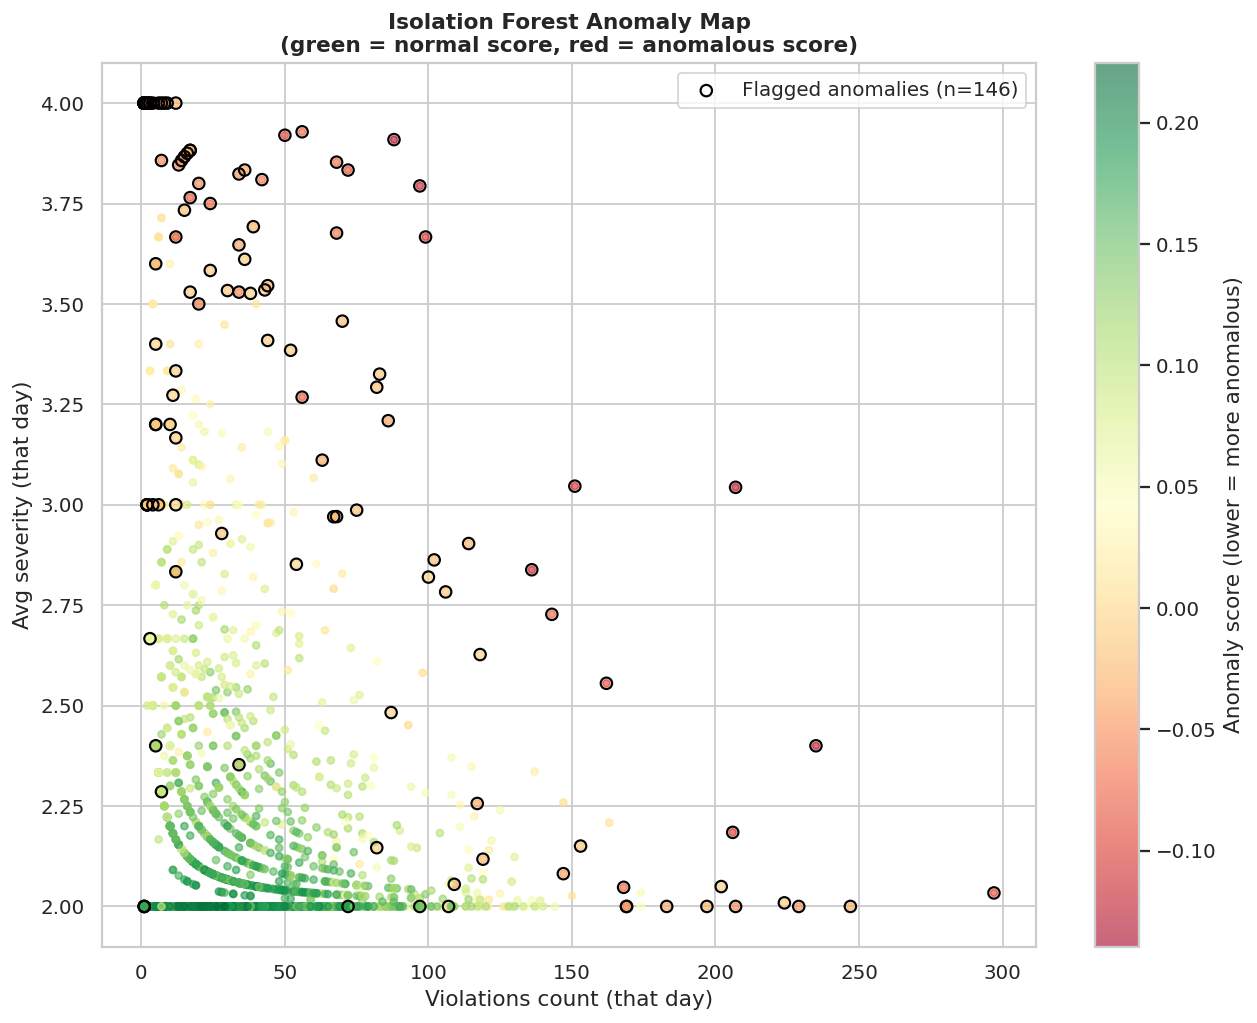

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    daily_features["violations_count"],
    daily_features["avg_severity"],
    c=daily_features["anomaly_score"],
    cmap="RdYlGn",
    s=15,
    alpha=0.6,
)

anomalies = daily_features[daily_features["is_anomaly"]]
ax.scatter(
    anomalies["violations_count"],
    anomalies["avg_severity"],
    facecolors="none",
    edgecolors="black",
    s=40,
    linewidths=1.2,
    label=f"Flagged anomalies (n={len(anomalies)})",
)

ax.set_xlabel("Violations count (that day)")
ax.set_ylabel("Avg severity (that day)")
ax.set_title(
    "Isolation Forest Anomaly Map\n(green = normal score, red = anomalous score)",
    fontweight="bold",
)
ax.legend()
plt.colorbar(scatter, label="Anomaly score (lower = more anomalous)")
plt.tight_layout()
plt.savefig("s4_isolation_forest_map.png")
plt.show()

## 6. Merge Anomaly Rate into `cluster_summary` and Save

In [12]:
cluster_summary = cluster_summary.merge(
    cluster_anomaly_rate[["cluster_id", "anomaly_rate"]],
    on="cluster_id", how="left"
)

# Updated cluster summary
cluster_summary.to_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_summary_updated.csv", index=False)

# Full daily feature + anomaly table
daily_features.to_csv("/content/drive/MyDrive/gridlock_flipkart/cluster_day_anomaly_scores.csv", index=False)

# Trained model AND scaler (both needed to score new data later)
joblib.dump(iso_forest, "/content/drive/MyDrive/gridlock_flipkart/isolation_forest_model.joblib")
joblib.dump(scaler,     "/content/drive/MyDrive/gridlock_flipkart/isolation_forest_scaler.joblib")

print("Saved:")
print(f"  cluster_summary.csv              — {cluster_summary.shape}")
print(f"  cluster_day_anomaly_scores.csv   — {daily_features.shape}")
print( "  isolation_forest_model.joblib    — trained IsolationForest")
print( "  isolation_forest_scaler.joblib   — fitted StandardScaler")
print()
print("NOTE: both .joblib files are required together to score new cluster-days")
print("      — the scaler must transform new data before it reaches the model.")

Saved:
  cluster_summary.csv              — (30, 35)
  cluster_day_anomaly_scores.csv   — (2909, 10)
  isolation_forest_model.joblib    — trained IsolationForest
  isolation_forest_scaler.joblib   — fitted StandardScaler

NOTE: both .joblib files are required together to score new cluster-days
      — the scaler must transform new data before it reaches the model.


In [13]:
# Reload test — confirms the saved artefacts work standalone
loaded_model  = joblib.load("isolation_forest_model.joblib")
loaded_scaler = joblib.load("isolation_forest_scaler.joblib")

test_row    = X.iloc[[0]]
test_scaled = loaded_scaler.transform(test_row)
test_pred   = loaded_model.predict(test_scaled)
test_score  = loaded_model.decision_function(test_scaled)

original_pred = iso_forest.predict(X_scaled[[0]])[0]

print(f"Reload test — prediction: {test_pred[0]},  score: {test_score[0]:.4f}")
print(f"Matches original prediction: {test_pred[0] == original_pred}")

Reload test — prediction: 1,  score: 0.1308
Matches original prediction: True
